
# SOB4ES - Comparación de Modelos

### CRISP-ML(Q) - Fase 5: Evaluación y selección del modelo final

Este notebook carga los modelos entrenados en los notebooks anteriores y compara su rendimiento sobre `eval.csv` de forma sistemática.

**Modelos comparados:**
1. Random Forest individual (modelos por target)
2. XGBoost individual (modelos por target)
3. Ridge Regression individual (modelos por target)
4. Random Forest multisalida
5. XGBoost multisalida
6. Ensemble de RegressorChains
7. MLP multisalida estándar
8. MLP con pérdida personalizada de correlación

**Métricas de comparación:**
- R2 global (promedio sobre todos los targets)
- R2 por target (para identificar grupos biológicos difíciles de predecir)
- RMSE y MAE globales

## 1.- Configuración

Configuración inicial del entorno, con librerías, variables globales y todo cargado.

In [1]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
import itertools

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')

DATA_DIR  = 'input/'
MODELS_BASE = 'output/models/'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    'mo_z',
    #'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Configuracion cargada.')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

Configuracion cargada.


## 2.- Carga de eval.csv

Se carga únicamente el dataset de evaluación final. Ninguno de los modelos ha visto estos datos durante el entrenamiento ni el tuning.

In [2]:
df_eval = pd.read_csv(os.path.join(DATA_DIR, 'eval.csv'))
X_eval  = df_eval[FEATURES_AUTORIZADAS]
y_eval  = df_eval[TARGETS]

print(f'eval.csv cargado: {X_eval.shape[0]} muestras x {X_eval.shape[1]} variables')


eval.csv cargado: 65 muestras x 32 variables


## 3.- Funciones auxiliares

Se definen las funciones necesarias para cargar cada tipo de modelo y calcular sus predicciones sobre `eval.csv`.

In [3]:
def metricas(y_true, y_pred, nombre):
    """Calcula R2, RMSE y MAE globales y devuelve un dict con los resultados."""
    r2   = r2_score(y_true, y_pred, multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))
    mae  = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    r2_targets = r2_score(y_true, y_pred, multioutput='raw_values')
    return {'modelo': nombre, 'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'r2_targets': r2_targets}


def predecir_ensamble_pkl(carpeta, prefijo, sufijo, n, X):
    """Carga n modelos .pkl y devuelve el promedio de sus predicciones."""
    preds = []
    for i in range(n):
        m = joblib.load(os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}{sufijo}.pkl'))
        preds.append(m.predict(X))
    return np.mean(preds, axis=0)


def predecir_ensamble_por_target(carpeta, prefijo_tpl, n, X):
    """
    Para modelos individuales (un modelo por target):
    carga n modelos por target y devuelve la matriz de predicciones.
    prefijo_tpl debe ser una funcion que recibe (target, seed_id) y devuelve el nombre del archivo.
    """
    y_pred = np.zeros((len(X), len(TARGETS)))
    for j, target in enumerate(TARGETS):
        preds_t = []
        for i in range(n):
            ruta = os.path.join(MODELS_BASE, carpeta, prefijo_tpl(target, i))
            m    = joblib.load(ruta)
            preds_t.append(m.predict(X))
        y_pred[:, j] = np.mean(preds_t, axis=0)
    return y_pred


class MLPMultiSalida(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers, in_size = [], n_inputs
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))
        self.red = nn.Sequential(*layers)
    def forward(self, x): return self.red(x)


def predecir_ensamble_mlp(carpeta, prefijo, n, X, config_file):
    """Carga n redes PyTorch y devuelve el promedio de sus predicciones."""
    cfg   = joblib.load(os.path.join(MODELS_BASE, carpeta, config_file))
    X_t   = torch.tensor(X.values, dtype=torch.float32).to(DEVICE)
    preds = []
    for i in range(n):
        model = MLPMultiSalida(X.shape[1], len(TARGETS), cfg['hidden'], cfg['dropout']).to(DEVICE)
        model.load_state_dict(torch.load(
            os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}.pt'), map_location=DEVICE
        ))
        model.eval()
        with torch.no_grad():
            preds.append(model(X_t).cpu().numpy())
    return np.mean(preds, axis=0)


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


## 4.- Predicciones de cada modelo

Se cargan y ejecutan todos los modelos sobre `eval.csv`. Este proceso puede tardar varios minutos dependiendo del número de modelos y el hardware disponible.

In [4]:
resultados = []
y_true = y_eval.values

print('Cargando modelos y generando predicciones...\n')

# 1. Random Forest individual
print('  [1/8] Random Forest individual...')
y_pred = predecir_ensamble_por_target('rf', lambda t, i: f'rf_prod_{t}_m{i}.pkl', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'RF Individual'))

# 2. XGBoost individual
print('  [2/8] XGBoost individual...')
y_pred = predecir_ensamble_por_target('xgb', lambda t, i: f'xgb_prod_{t}_exp{i}.pkl', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'XGBoost Individual'))

# 3. Ridge individual
print('  [3/8] Ridge Regression...')
y_pred_ridge = np.zeros((len(X_eval), len(TARGETS)))
for j, target in enumerate(TARGETS):
    m = joblib.load(os.path.join(MODELS_BASE, 'reg', f'ridge_prod_{target}.pkl'))
    y_pred_ridge[:, j] = m.predict(X_eval)
resultados.append(metricas(y_true, y_pred_ridge, 'Regresión Individual'))

# 4. RF multisalida
print('  [4/8] Random Forest multisalida...')
y_pred = predecir_ensamble_pkl('rf_multi', 'rf_multi_m', '', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'RandomForest Multisalida'))

# 5. XGBoost multisalida
print('  [5/8] XGBoost multisalida...')
y_pred = predecir_ensamble_pkl('xgb_multi', 'xgb_multi_exp', '', 5, X_eval)
resultados.append(metricas(y_true, y_pred, 'XGBoost Multisalida'))

# 6. RegressorChain
print('  [6/8] Ensemble RegressorChain...')
N_CHAINS   = 10
preds_chain = []
for chain_id in range(N_CHAINS):
    cadena = joblib.load(os.path.join(MODELS_BASE, 'chain', f'chain_{chain_id}.pkl'))
    preds_chain.append(cadena.predict(X_eval))
y_pred = np.mean(preds_chain, axis=0)
resultados.append(metricas(y_true, y_pred, 'Random Forest con RegressorChain'))

# 7. MLP estandar
print('  [7/8] MLP multisalida estandar...')
y_pred = predecir_ensamble_mlp('mlp', 'mlp_prod_', 5, X_eval, 'mlp_config.pkl')
resultados.append(metricas(y_true, y_pred, 'MLP Estandar'))

# 8. MLP con perdida personalizada
print('  [8/8] MLP perdida personalizada...')
y_pred = predecir_ensamble_mlp('mlp_custom', 'mlp_custom_', 5, X_eval, 'mlp_custom_config.pkl')
resultados.append(metricas(y_true, y_pred, 'MLP Perdida Custom'))

print('\nPredicciones completadas...')


Cargando modelos y generando predicciones...

  [1/8] Random Forest individual...


  [2/8] XGBoost individual...


  [3/8] Ridge Regression...
  [4/8] Random Forest multisalida...


  [5/8] XGBoost multisalida...


  [6/8] Ensemble RegressorChain...


  [7/8] MLP multisalida estandar...
  [8/8] MLP perdida personalizada...

Predicciones completadas...


## 5.- Tabla comparativa global

Se muestra la comparación ordenada por R2 descendente. 

El mejor modelo es el que tiene R2 más alto y RMSE/MAE más bajos.

Comparacion de modelos (ordenado por R2 descendente):
                             Modelo  R2 global    RMSE     MAE
1          RandomForest Multisalida     0.0968  0.9193  0.7020
2                     RF Individual     0.0866  0.9194  0.6938
3               XGBoost Multisalida     0.0804  0.9186  0.6825
4  Random Forest con RegressorChain     0.0766  0.9180  0.6805
5                XGBoost Individual     0.0671  0.9298  0.7053
6              Regresión Individual    -0.0133  0.9658  0.7430
7                      MLP Estandar    -0.0174  0.9533  0.7036
8                MLP Perdida Custom    -0.0670  0.9640  0.7088

Mejor modelo: RandomForest Multisalida (R2 = 0.0968)


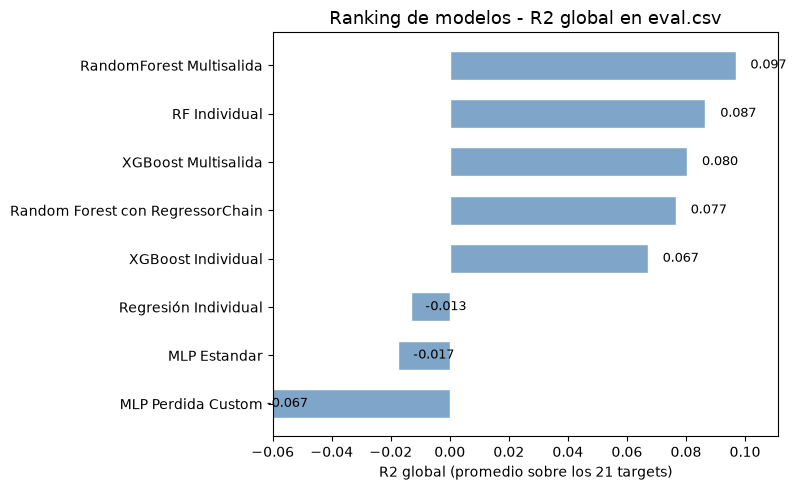

In [5]:
tabla = pd.DataFrame([{
    'Modelo': r['modelo'],
    'R2 global': r['R2'],
    'RMSE':      r['RMSE'],
    'MAE':       r['MAE']
} for r in resultados]).sort_values('R2 global', ascending=False).reset_index(drop=True)

tabla.index += 1  # ranking desde 1
print('Comparacion de modelos (ordenado por R2 descendente):')
print('=' * 60)
print(tabla.to_string())
print('=' * 60)
print(f'\nMejor modelo: {tabla.iloc[0]["Modelo"]} (R2 = {tabla.iloc[0]["R2 global"]})')

# Grafico: ranking de modelos por R2 global
fig, ax = plt.subplots(figsize=(8, 5))
_orden = tabla.sort_values('R2 global')
ax.barh(_orden['Modelo'], _orden['R2 global'], color=PALETTE['blue'], edgecolor='white', height=0.6)
for i, v in enumerate(_orden['R2 global']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('R2 global (promedio sobre los 21 targets)')
ax.set_title('Ranking de modelos - R2 global en eval.csv', fontsize=13)
ax.set_xlim(-0.060, _orden['R2 global'].max() * 1.15)
plt.tight_layout()
plt.show()

## 6.- Comparación por target

Se muestra el R2 de cada modelo para cada grupo biológico. 

Esto permite identificar para que grupos funciona mejor cada enfoque y si hay grupos que ninguno de los modelos predice bien (posiblemente por falta de datos o por relaciones muy ruidosas con las variables predictoras).

R2 por target y modelo:


Modelo                   RandomForest Multisalida  RF Individual  XGBoost Multisalida  Random Forest con RegressorChain  XGBoost Individual  Regresión Individual  MLP Estandar  MLP Perdida Custom
Target                                                                                                                                                                                             
GLOBAL                                     0.0968         0.0866               0.0804                            0.0766              0.0671               -0.0133       -0.0174             -0.0670
nematode_shannon_z                         0.1514         0.1335               0.2163                            0.1489              0.1461               -0.0019        0.1089              0.0977
macro_shannon_z                            0.1966         0.3141               0.3795                            0.2906              0.2582                0.1191        0.2334              0.2528
earthworm_shannon_z

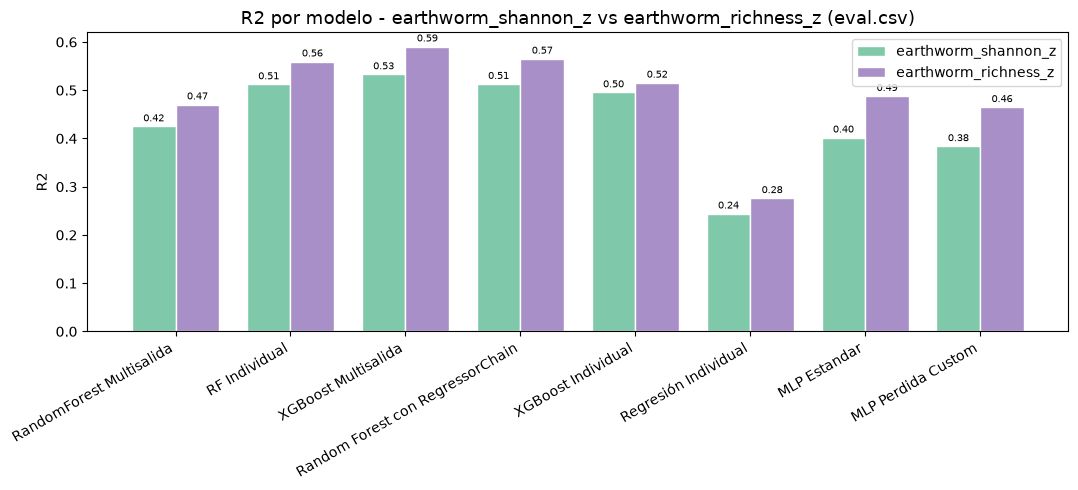

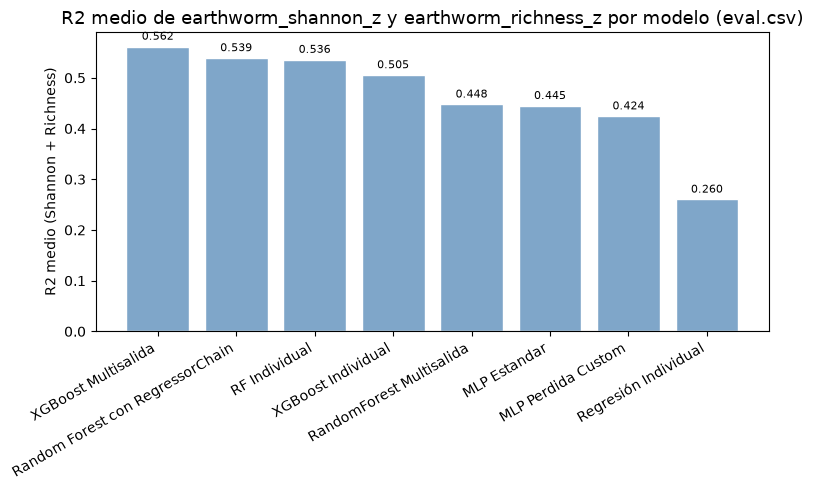

In [6]:
# Construimos una tabla con R2 por target para cada modelo
filas = []
for r in resultados:
    fila = {'Target': 'GLOBAL', 'Modelo': r['modelo'], 'R2': r['R2']}
    filas.append(fila)
    for t, r2_t in zip(TARGETS, r['r2_targets']):
        filas.append({'Target': t, 'Modelo': r['modelo'], 'R2': round(float(r2_t), 4)})

df_r2 = pd.DataFrame(filas).pivot(index='Target', columns='Modelo', values='R2')

# Ordenamos los targets: GLOBAL primero, luego por R2 medio descendente
orden = ['GLOBAL'] + [t for t in TARGETS]
df_r2 = df_r2.loc[orden]

# Ordenamos las columnas por R2 global descendente
orden_modelos = tabla['Modelo'].tolist()
df_r2 = df_r2[orden_modelos]

print('R2 por target y modelo:')
print('=' * 120)
print(df_r2.to_string())
print('=' * 120)
print('\nTargets con R2 medio < 0.2 en todos los modelos (posiblemente difíciles de predecir):')
media_por_target = df_r2.drop('GLOBAL').mean(axis=1)
dificiles = media_por_target[media_por_target < 0.2]
if len(dificiles) > 0:
    for t, v in dificiles.items():
        print(f'  {t:30} R2 medio: {v:.4f}')
else:
    print('  Ninguno.')

# Grafico: R2 por modelo para los targets principales (Shannon y Richness de lombrices)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]  # colores fijos del proyecto: shannon / richness

_df_main = df_r2.loc[_targets_plot]
_x = np.arange(len(orden_modelos))
_width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
for i, (tgt, col) in enumerate(zip(_targets_plot, _colors_plot)):
    offset = (i - 0.5) * _width
    bars = ax.bar(_x + offset, _df_main.loc[tgt, orden_modelos], _width,
                   label=tgt, color=col, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(_x)
ax.set_xticklabels(orden_modelos, rotation=30, ha='right')
ax.set_ylabel('R2')
ax.set_title('R2 por modelo - earthworm_shannon_z vs earthworm_richness_z (eval.csv)', fontsize=13)
ax.axhline(0, color=PALETTE['gray'], linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# Grafico: R2 medio (Shannon + Richness) por modelo
_media_principal = _df_main.loc[_targets_plot, orden_modelos].mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(_media_principal.index, _media_principal.values, color=PALETTE['blue'], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticklabels(_media_principal.index, rotation=30, ha='right')
ax.set_ylabel('R2 medio (Shannon + Richness)')
ax.set_title('R2 medio de earthworm_shannon_z y earthworm_richness_z por modelo (eval.csv)', fontsize=13)
ax.axhline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

# 7.- Exportación de las comparaciones de regresión

In [7]:
os.makedirs('output/regresion', exist_ok=True)

# Guardamos la tabla comparativa para referencia futura
tabla.to_csv('output/regresion/comparacion_modelos.csv', index=False)
df_r2.to_csv('output/regresion/r2_por_target.csv')

print('Resultados guardados en output/regresion/comparacion_modelos.csv y output/regresion/r2_por_target.csv')


Resultados guardados en output/regresion/comparacion_modelos.csv y output/regresion/r2_por_target.csv


# 8.- Prueba de clasificación

En este notebook también se realiza una pequeña prueba de clasificación para comprobar si los rankings cambian cuando se hace las pruebas tenienod en cuenta los resultados de regresión o no.

Iniciando Análisis Avanzado con Métricas de Clasificación Blanda...
[INFO] Cargado train.csv con éxito. Umbrales calculados sobre train + eval.

Generando predicciones para los 8 modelos...
  [1/8] Recalculando RF Individual...


  [2/8] Recalculando XGBoost Individual...


  [3/8] Recalculando Regresión Individual (Ridge)...
  [4/8] Recalculando RandomForest Multisalida...


  [5/8] Recalculando XGBoost Multisalida...


  [6/8] Recalculando Random Forest con RegressorChain...


  [7/8] Recalculando MLP Estandar...
  [8/8] Recalculando MLP Perdida Custom...
¡Predicciones obtenidas con éxito!


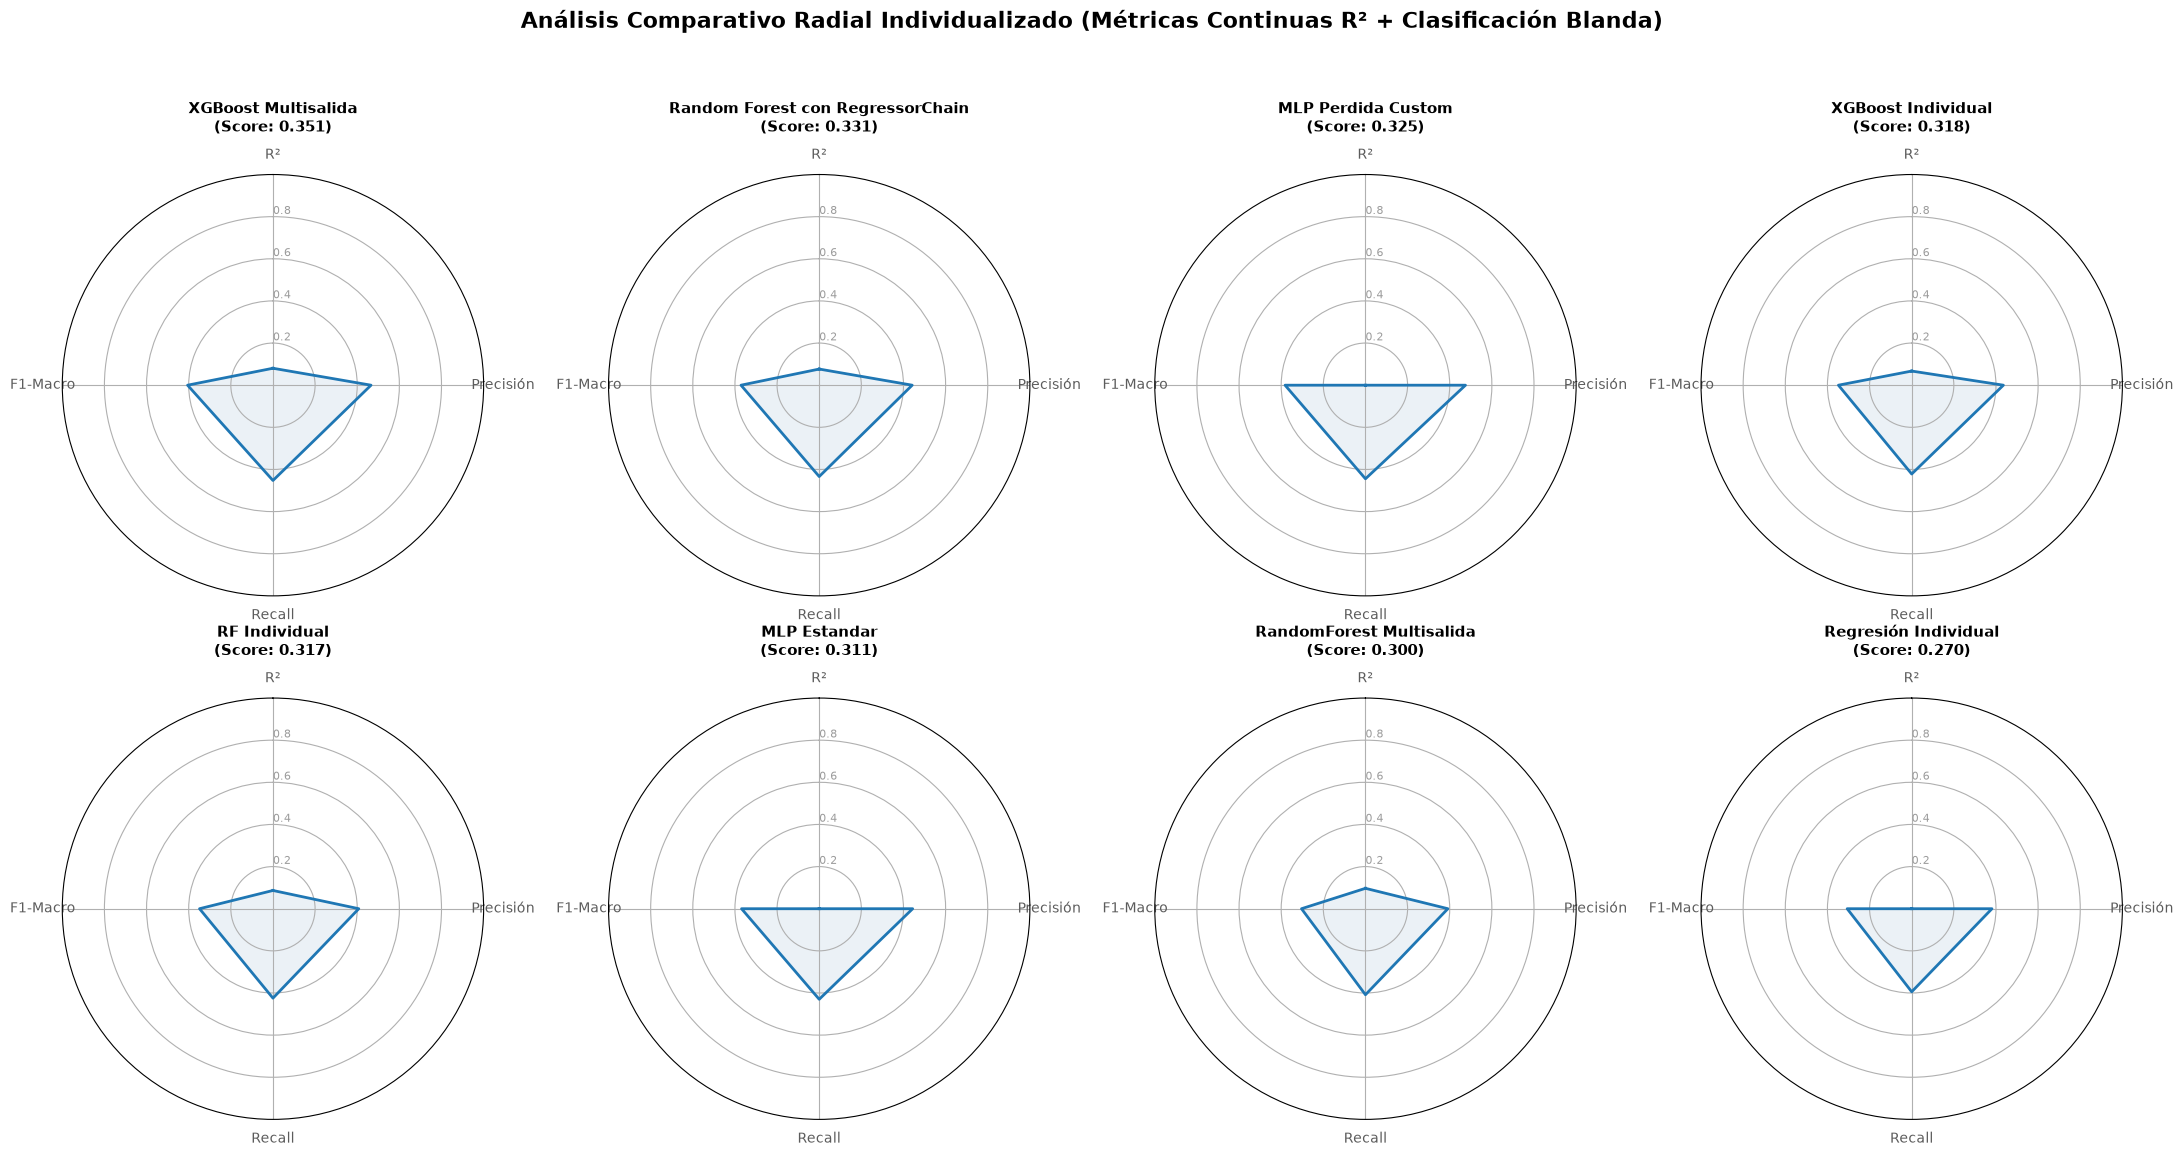

  Top 8 modelos (Métricas de Regresión Original + Clasificación Blanda)  
Top 1: XGBoost Multisalida                 | Compuesto: 0.3509 | R2:  0.0804 | P: 0.4655 | R: 0.4524 | F1: 0.4052
Top 2: Random Forest con RegressorChain    | Compuesto: 0.3307 | R2:  0.0766 | P: 0.4414 | R: 0.4337 | F1: 0.3712
Top 3: MLP Perdida Custom                  | Compuesto: 0.3252 | R2: -0.0670 | P: 0.4748 | R: 0.4444 | F1: 0.3816
Top 4: XGBoost Individual                  | Compuesto: 0.3179 | R2:  0.0671 | P: 0.4351 | R: 0.4216 | F1: 0.3478
Top 5: RF Individual                       | Compuesto: 0.3168 | R2:  0.0866 | P: 0.4074 | R: 0.4245 | F1: 0.3485
Top 6: MLP Estandar                        | Compuesto: 0.3106 | R2: -0.0174 | P: 0.4437 | R: 0.4300 | F1: 0.3687
Top 7: RandomForest Multisalida            | Compuesto: 0.3000 | R2:  0.0968 | P: 0.3912 | R: 0.4084 | F1: 0.3035
Top 8: Regresión Individual                | Compuesto: 0.2704 | R2: -0.0133 | P: 0.3810 | R: 0.3943 | F1: 0.3063


In [8]:
# Paso 1: Carga de datos y preparación segura de percentiles
print("Iniciando Análisis Avanzado con Métricas de Clasificación Blanda...")
try:
    # Intentamos cargar train.csv usando la ruta configurada en el notebook
    df_train_tmp = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
    df_combinado = pd.concat([df_train_tmp[TARGETS], df_eval[TARGETS]], axis=0)
    print("[INFO] Cargado train.csv con éxito. Umbrales calculados sobre train + eval.")
except Exception as e:
    df_combinado = df_eval[TARGETS]
    print("[WARN] No se pudo cargar train.csv, usando solo eval.csv para umbrales:", e)

os.makedirs('output/regresion/graphs', exist_ok=True)

y_true = y_eval.values

# Paso 2: Recalcular predicciones de todos los modelos de forma explícita y segura
dicc_preds = {}
print("\nGenerando predicciones para los 8 modelos...")

# 1. Random Forest individual
print("  [1/8] Recalculando RF Individual...")
dicc_preds['RF Individual'] = predecir_ensamble_por_target('rf', lambda t, i: f'rf_prod_{t}_m{i}.pkl', 5, X_eval)

# 2. XGBoost individual
print("  [2/8] Recalculando XGBoost Individual...")
dicc_preds['XGBoost Individual'] = predecir_ensamble_por_target('xgb', lambda t, i: f'xgb_prod_{t}_exp{i}.pkl', 5, X_eval)

# 3. Ridge individual
print("  [3/8] Recalculando Regresión Individual (Ridge)...")
y_pred_ridge = np.zeros((len(X_eval), len(TARGETS)))
for j, target in enumerate(TARGETS):
    m = joblib.load(os.path.join(MODELS_BASE, 'reg', f'ridge_prod_{target}.pkl'))
    y_pred_ridge[:, j] = m.predict(X_eval)
dicc_preds['Regresión Individual'] = y_pred_ridge

# 4. RF multisalida
print("  [4/8] Recalculando RandomForest Multisalida...")
dicc_preds['RandomForest Multisalida'] = predecir_ensamble_pkl('rf_multi', 'rf_multi_m', '', 5, X_eval)

# 5. XGBoost multisalida
print("  [5/8] Recalculando XGBoost Multisalida...")
dicc_preds['XGBoost Multisalida'] = predecir_ensamble_pkl('xgb_multi', 'xgb_multi_exp', '', 5, X_eval)

# 6. RegressorChain
print("  [6/8] Recalculando Random Forest con RegressorChain...")
N_CHAINS = 10
preds_chain = []
for chain_id in range(N_CHAINS):
    cadena = joblib.load(os.path.join(MODELS_BASE, 'chain', f'chain_{chain_id}.pkl'))
    preds_chain.append(cadena.predict(X_eval))
dicc_preds['Random Forest con RegressorChain'] = np.mean(preds_chain, axis=0)

# 7. MLP estandar
print("  [7/8] Recalculando MLP Estandar...")
dicc_preds['MLP Estandar'] = predecir_ensamble_mlp('mlp', 'mlp_prod_', 5, X_eval, 'mlp_config.pkl')

# 8. MLP con perdida personalizada
print("  [8/8] Recalculando MLP Perdida Custom...")
dicc_preds['MLP Perdida Custom'] = predecir_ensamble_mlp('mlp_custom', 'mlp_custom_', 5, X_eval, 'mlp_custom_config.pkl')

print("¡Predicciones obtenidas con éxito!")

# Paso 3: Calcular métricas combinadas (Regresión R² + Clasificación)
filas_radar = []

for nombre_modelo, y_pred in dicc_preds.items():
    # Extraer el R2 global calculado previamente en la Celda 4 de resultados
    r2_global = 0.0
    for res in resultados:
        if res['modelo'] == nombre_modelo:
            r2_global = res['R2']
            break
            
    # Calcular métricas de clasificación blanda por target discretizando en Bajo/Medio/Alto
    precisions, recalls, f1s = [], [], []
    for j, target in enumerate(TARGETS):
        valores_ref = df_combinado[target].dropna().values
        p33 = np.percentile(valores_ref, 33)
        p66 = np.percentile(valores_ref, 66)
        
        t_disc = np.zeros_like(y_true[:, j], dtype=int)
        t_disc[y_true[:, j] > p33] = 1
        t_disc[y_true[:, j] > p66] = 2
        
        p_disc = np.zeros_like(y_pred[:, j], dtype=int)
        p_disc[y_pred[:, j] > p33] = 1
        p_disc[y_pred[:, j] > p66] = 2
        
        precisions.append(precision_score(t_disc, p_disc, average='macro', zero_division=0))
        recalls.append(recall_score(t_disc, p_disc, average='macro', zero_division=0))
        f1s.append(f1_score(t_disc, p_disc, average='macro', zero_division=0))
        
    precision_m = np.mean(precisions)
    recall_m = np.mean(recalls)
    f1_m = np.mean(f1s)
    
    # Puntuación compuesta balanceada (R2 acotado a 0 si es muy bajo/negativo para visualización uniforme)
    r2_clipped = max(0, r2_global)
    score_compuesto = (r2_clipped + precision_m + recall_m + f1_m) / 4
    
    filas_radar.append({
        'Modelo': nombre_modelo,
        'R2': r2_global,
        'Precision': precision_m,
        'Recall': recall_m,
        'F1_Macro': f1_m,
        'Score_Compuesto': score_compuesto
    })

df_radar_orig = pd.DataFrame(filas_radar).sort_values(by='Score_Compuesto', ascending=False)

# Paso 4: Generación del Mosaico de Gráficos de Radar
categorias = ['R²', 'Precisión', 'Recall', 'F1-Macro']
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, axes = plt.subplots(2, 4, figsize=(22, 11), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

os.makedirs('output', exist_ok=True)

for idx, (index, fila) in enumerate(df_radar_orig.iterrows()):
    ax = axes[idx]
    
    # Valores mapeados (R2 acotado a 0 para mantener escala proporcional positiva de 0 a 1)
    valores = [max(0, fila['R2']), fila['Precision'], fila['Recall'], fila['F1_Macro']]
    valores += valores[:1]
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    plt.sca(ax)
    plt.xticks(angulos[:-1], categorias, color=PALETTE['gray_dark'], size=10)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color=PALETTE['gray'], size=8)
    plt.ylim(0, 1)
    
    # Dibujar polígono en el mosaico
    ax.plot(angulos, valores, linewidth=2, linestyle='solid')
    ax.fill(angulos, valores, color=PALETTE['blue'], alpha=0.15)
    ax.set_title(f"{fila['Modelo']}\n(Score: {fila['Score_Compuesto']:.3f})", fontsize=11, fontweight='bold', pad=12)
    
    # Guardar gráfico radial individual
    fig_ind, ax_ind = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
    ax_ind.set_theta_offset(np.pi / 2)
    ax_ind.set_theta_direction(-1)
    ax_ind.plot(angulos, valores, linewidth=2, linestyle='solid', color=PALETTE['green'])
    ax_ind.fill(angulos, valores, color=PALETTE['green'], alpha=0.15)
    ax_ind.set_title(f"Análisis Radial: {fila['Modelo']}\nScore Compuesto: {fila['Score_Compuesto']:.4f}", fontsize=12, fontweight='bold', pad=15)
    ax_ind.set_xticklabels(categorias)
    ax_ind.set_ylim(0, 1)
    
    nombre_archivo = f"output/regresion/graphs/radar_regresion_{fila['Modelo'].lower().replace(' ', '_')}.png"
    fig_ind.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.close(fig_ind)

# Formatear mosaico general y guardar
fig.suptitle("Análisis Comparativo Radial Individualizado (Métricas Continuas R² + Clasificación Blanda)", fontsize=16, fontweight='bold', y=1.04)
fig.tight_layout()
fig.savefig('output/regresion/graphs/mosaico_radar_regresion.png', dpi=300, bbox_inches='tight')
plt.show()

# Paso 5: Imprimir el Ranking Top 8 Final

print("  Top 8 modelos (Métricas de Regresión Original + Clasificación Blanda)  ")

for i, (idx, fila) in enumerate(df_radar_orig.iterrows(), 1):
    print(f"Top {i}: {fila['Modelo']:<35} | Compuesto: {fila['Score_Compuesto']:.4f} | R2: {fila['R2']:>7.4f} | P: {fila['Precision']:.4f} | R: {fila['Recall']:.4f} | F1: {fila['F1_Macro']:.4f}")


In [9]:
# Paso 6: Metricas de clasificacion blanda (R2, Precision, Recall, F1) POR TARGET para cada modelo
print("Calculando metricas por target para el analisis por target...")

# Mapeo fijo modelo -> color, para que cada modelo tenga siempre el mismo color
# en todos los radares por target (facilita comparar visualmente entre targets)
modelos_lista = list(dicc_preds.keys())
color_por_modelo = {m: c for m, c in zip(modelos_lista, palette_cycle(len(modelos_lista)))}

filas_radar_target = []
for nombre_modelo, y_pred in dicc_preds.items():
    r2_por_target = r2_score(y_true, y_pred, multioutput='raw_values')

    for j, target in enumerate(TARGETS):
        valores_ref = df_combinado[target].dropna().values
        p33 = np.percentile(valores_ref, 33)
        p66 = np.percentile(valores_ref, 66)

        t_disc = np.zeros_like(y_true[:, j], dtype=int)
        t_disc[y_true[:, j] > p33] = 1
        t_disc[y_true[:, j] > p66] = 2

        p_disc = np.zeros_like(y_pred[:, j], dtype=int)
        p_disc[y_pred[:, j] > p33] = 1
        p_disc[y_pred[:, j] > p66] = 2

        precision_t = precision_score(t_disc, p_disc, average='macro', zero_division=0)
        recall_t    = recall_score(t_disc, p_disc, average='macro', zero_division=0)
        f1_t        = f1_score(t_disc, p_disc, average='macro', zero_division=0)
        r2_t        = float(r2_por_target[j])
        score_t     = (max(0, r2_t) + precision_t + recall_t + f1_t) / 4

        filas_radar_target.append({
            'Target': target,
            'Modelo': nombre_modelo,
            'R2': r2_t,
            'Precision': precision_t,
            'Recall': recall_t,
            'F1_Macro': f1_t,
            'Score_Compuesto': score_t
        })

df_radar_target = pd.DataFrame(filas_radar_target)
print(f"Metricas por target calculadas para {df_radar_target['Modelo'].nunique()} modelos "
      f"x {df_radar_target['Target'].nunique()} targets...")

Calculando metricas por target para el analisis por target...


Metricas por target calculadas para 8 modelos x 21 targets...


  Top 8 modelos por target (R2 + Clasificación)  



nematode_shannon_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.3889 | R2:  0.2163 | P: 0.4926 | R: 0.4572 | F1: 0.3895
  Top 2: MLP Perdida Custom                  | Compuesto: 0.2787 | R2:  0.0977 | P: 0.3013 | R: 0.4043 | F1: 0.3117
  Top 3: XGBoost Individual                  | Compuesto: 0.2768 | R2:  0.1461 | P: 0.2736 | R: 0.3899 | F1: 0.2978
  Top 4: RandomForest Multisalida            | Compuesto: 0.2734 | R2:  0.1514 | P: 0.2791 | R: 0.3855 | F1: 0.2776
  Top 5: Regresión Individual                | Compuesto: 0.2686 | R2: -0.0019 | P: 0.4122 | R: 0.3615 | F1: 0.3008
  Top 6: Random Forest con RegressorChain    | Compuesto: 0.2569 | R2:  0.1489 | P: 0.2500 | R: 0.3587 | F1: 0.2699
  Top 7: RF Individual                       | Compuesto: 0.2558 | R2:  0.1335 | P: 0.2508 | R: 0.3710 | F1: 0.2678
  Top 8: MLP Estandar                        | Compuesto: 0.2298 | R2:  0.1089 | P: 0.2366 | R: 0.3275 | F1: 0.2460



macro_shannon_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.5096 | R2:  0.3795 | P: 0.6102 | R: 0.5252 | F1: 0.5233
  Top 2: Random Forest con RegressorChain    | Compuesto: 0.5008 | R2:  0.2906 | P: 0.7114 | R: 0.5091 | F1: 0.4923
  Top 3: MLP Perdida Custom                  | Compuesto: 0.4838 | R2:  0.2528 | P: 0.6078 | R: 0.5498 | F1: 0.5246
  Top 4: RF Individual                       | Compuesto: 0.4806 | R2:  0.3141 | P: 0.6939 | R: 0.4781 | F1: 0.4361
  Top 5: MLP Estandar                        | Compuesto: 0.4698 | R2:  0.2334 | P: 0.6223 | R: 0.5220 | F1: 0.5013
  Top 6: XGBoost Individual                  | Compuesto: 0.3963 | R2:  0.2582 | P: 0.5141 | R: 0.4295 | F1: 0.3834
  Top 7: RandomForest Multisalida            | Compuesto: 0.3473 | R2:  0.1966 | P: 0.4633 | R: 0.4133 | F1: 0.3160
  Top 8: Regresión Individual                | Compuesto: 0.2815 | R2:  0.1191 | P: 0.3370 | R: 0.3855 | F1: 0.2843



earthworm_shannon_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.7018 | R2:  0.5328 | P: 0.7703 | R: 0.7578 | F1: 0.7462
  Top 2: RF Individual                       | Compuesto: 0.6848 | R2:  0.5121 | P: 0.7564 | R: 0.7427 | F1: 0.7280
  Top 3: Random Forest con RegressorChain    | Compuesto: 0.6826 | R2:  0.5128 | P: 0.7467 | R: 0.7403 | F1: 0.7307
  Top 4: XGBoost Individual                  | Compuesto: 0.6431 | R2:  0.4954 | P: 0.7051 | R: 0.6925 | F1: 0.6794
  Top 5: RandomForest Multisalida            | Compuesto: 0.5826 | R2:  0.4249 | P: 0.6897 | R: 0.6366 | F1: 0.5793
  Top 6: MLP Estandar                        | Compuesto: 0.5718 | R2:  0.4017 | P: 0.6469 | R: 0.6247 | F1: 0.6140
  Top 7: MLP Perdida Custom                  | Compuesto: 0.5384 | R2:  0.3838 | P: 0.6011 | R: 0.5944 | F1: 0.5743
  Top 8: Regresión Individual                | Compuesto: 0.3862 | R2:  0.2441 | P: 0.4279 | R: 0.4720 | F1: 0.4008



orib_shannon_z:
  Top 1: MLP Perdida Custom                  | Compuesto: 0.3317 | R2:  0.2427 | P: 0.3918 | R: 0.4359 | F1: 0.2564
  Top 2: MLP Estandar                        | Compuesto: 0.3054 | R2:  0.2606 | P: 0.3443 | R: 0.3897 | F1: 0.2268
  Top 3: RF Individual                       | Compuesto: 0.2997 | R2:  0.1890 | P: 0.3501 | R: 0.4231 | F1: 0.2368
  Top 4: XGBoost Multisalida                 | Compuesto: 0.2994 | R2:  0.2245 | P: 0.2978 | R: 0.4077 | F1: 0.2678
  Top 5: RandomForest Multisalida            | Compuesto: 0.2809 | R2:  0.1682 | P: 0.3880 | R: 0.3846 | F1: 0.1828
  Top 6: Random Forest con RegressorChain    | Compuesto: 0.2454 | R2:  0.2391 | P: 0.2244 | R: 0.3231 | F1: 0.1949
  Top 7: Regresión Individual                | Compuesto: 0.1977 | R2:  0.1007 | P: 0.2444 | R: 0.3051 | F1: 0.1407
  Top 8: XGBoost Individual                  | Compuesto: 0.1976 | R2:  0.1500 | P: 0.2076 | R: 0.2846 | F1: 0.1481


...


bac_asv_richness_z:
  Top 1: Regresión Individual                | Compuesto: 0.3470 | R2: -0.0826 | P: 0.5003 | R: 0.4573 | F1: 0.4305
  Top 2: MLP Estandar                        | Compuesto: 0.3465 | R2: -0.1185 | P: 0.4861 | R: 0.4591 | F1: 0.4408
  Top 3: XGBoost Multisalida                 | Compuesto: 0.3330 | R2:  0.0260 | P: 0.4659 | R: 0.4234 | F1: 0.4167
  Top 4: MLP Perdida Custom                  | Compuesto: 0.3304 | R2: -0.1754 | P: 0.4667 | R: 0.4414 | F1: 0.4135
  Top 5: RandomForest Multisalida            | Compuesto: 0.3256 | R2:  0.0136 | P: 0.5943 | R: 0.3982 | F1: 0.2964
  Top 6: RF Individual                       | Compuesto: 0.3223 | R2:  0.0146 | P: 0.4753 | R: 0.4205 | F1: 0.3787
  Top 7: XGBoost Individual                  | Compuesto: 0.3072 | R2:  0.0010 | P: 0.4591 | R: 0.4081 | F1: 0.3605
  Top 8: Random Forest con RegressorChain    | Compuesto: 0.2887 | R2: -0.0338 | P: 0.4511 | R: 0.3689 | F1: 0.3347



fun_asv_richness_z:
  Top 1: MLP Perdida Custom                  | Compuesto: 0.3976 | R2:  0.0095 | P: 0.6786 | R: 0.4733 | F1: 0.4290
  Top 2: MLP Estandar                        | Compuesto: 0.3490 | R2:  0.0230 | P: 0.6000 | R: 0.4089 | F1: 0.3641
  Top 3: Random Forest con RegressorChain    | Compuesto: 0.3149 | R2: -0.0230 | P: 0.4667 | R: 0.4178 | F1: 0.3750
  Top 4: XGBoost Multisalida                 | Compuesto: 0.2732 | R2: -0.0654 | P: 0.3876 | R: 0.3578 | F1: 0.3475
  Top 5: Regresión Individual                | Compuesto: 0.2707 | R2:  0.0083 | P: 0.4896 | R: 0.3467 | F1: 0.2384
  Top 6: RF Individual                       | Compuesto: 0.2350 | R2: -0.0320 | P: 0.2693 | R: 0.3778 | F1: 0.2931
  Top 7: RandomForest Multisalida            | Compuesto: 0.2210 | R2: -0.0058 | P: 0.2670 | R: 0.3556 | F1: 0.2614
  Top 8: XGBoost Individual                  | Compuesto: 0.1744 | R2: -0.0306 | P: 0.1538 | R: 0.3333 | F1: 0.2105



euk_asv_richness_z:
  Top 1: XGBoost Multisalida                 | Compuesto: 0.5139 | R2:  0.2180 | P: 0.6370 | R: 0.5988 | F1: 0.6018
  Top 2: MLP Estandar                        | Compuesto: 0.5129 | R2:  0.2580 | P: 0.6286 | R: 0.5830 | F1: 0.5822
  Top 3: Random Forest con RegressorChain    | Compuesto: 0.5062 | R2:  0.2874 | P: 0.6481 | R: 0.5505 | F1: 0.5387
  Top 4: MLP Perdida Custom                  | Compuesto: 0.4685 | R2:  0.1937 | P: 0.5756 | R: 0.5541 | F1: 0.5505
  Top 5: RF Individual                       | Compuesto: 0.4542 | R2:  0.2455 | P: 0.6153 | R: 0.4906 | F1: 0.4652
  Top 6: XGBoost Individual                  | Compuesto: 0.4526 | R2:  0.1559 | P: 0.6281 | R: 0.5224 | F1: 0.5038
  Top 7: RandomForest Multisalida            | Compuesto: 0.4468 | R2:  0.1937 | P: 0.7560 | R: 0.4596 | F1: 0.3779
  Top 8: Regresión Individual                | Compuesto: 0.3744 | R2:  0.0561 | P: 0.5185 | R: 0.4755 | F1: 0.4474



oomy_asv_richness_z:
  Top 1: Random Forest con RegressorChain    | Compuesto: 0.4392 | R2:  0.2186 | P: 0.5682 | R: 0.4869 | F1: 0.4831
  Top 2: MLP Perdida Custom                  | Compuesto: 0.3925 | R2:  0.0203 | P: 0.5306 | R: 0.5121 | F1: 0.5069
  Top 3: RandomForest Multisalida            | Compuesto: 0.3898 | R2:  0.1992 | P: 0.5755 | R: 0.4065 | F1: 0.3779
  Top 4: XGBoost Individual                  | Compuesto: 0.3809 | R2:  0.1859 | P: 0.4822 | R: 0.4281 | F1: 0.4273
  Top 5: RF Individual                       | Compuesto: 0.3749 | R2:  0.1849 | P: 0.4771 | R: 0.4181 | F1: 0.4195
  Top 6: Regresión Individual                | Compuesto: 0.3574 | R2:  0.1124 | P: 0.5444 | R: 0.3965 | F1: 0.3764
  Top 7: XGBoost Multisalida                 | Compuesto: 0.3495 | R2:  0.1728 | P: 0.4253 | R: 0.3957 | F1: 0.4041
  Top 8: MLP Estandar                        | Compuesto: 0.3305 | R2:  0.0452 | P: 0.4494 | R: 0.4213 | F1: 0.4059



cerc_asv_richness_z:
  Top 1: Regresión Individual                | Compuesto: 0.3440 | R2:  0.0890 | P: 0.5148 | R: 0.4037 | F1: 0.3685
  Top 2: XGBoost Multisalida                 | Compuesto: 0.3134 | R2:  0.1028 | P: 0.4342 | R: 0.3545 | F1: 0.3623
  Top 3: XGBoost Individual                  | Compuesto: 0.2979 | R2:  0.1364 | P: 0.3955 | R: 0.3327 | F1: 0.3270
  Top 4: Random Forest con RegressorChain    | Compuesto: 0.2752 | R2:  0.1175 | P: 0.4015 | R: 0.3098 | F1: 0.2721
  Top 5: RF Individual                       | Compuesto: 0.2703 | R2:  0.1116 | P: 0.3912 | R: 0.3070 | F1: 0.2715
  Top 6: RandomForest Multisalida            | Compuesto: 0.2696 | R2:  0.1217 | P: 0.3935 | R: 0.3269 | F1: 0.2362
  Top 7: MLP Estandar                        | Compuesto: 0.2663 | R2: -0.0431 | P: 0.4206 | R: 0.3316 | F1: 0.3128
  Top 8: MLP Perdida Custom                  | Compuesto: 0.2581 | R2:  0.0384 | P: 0.4132 | R: 0.3013 | F1: 0.2794


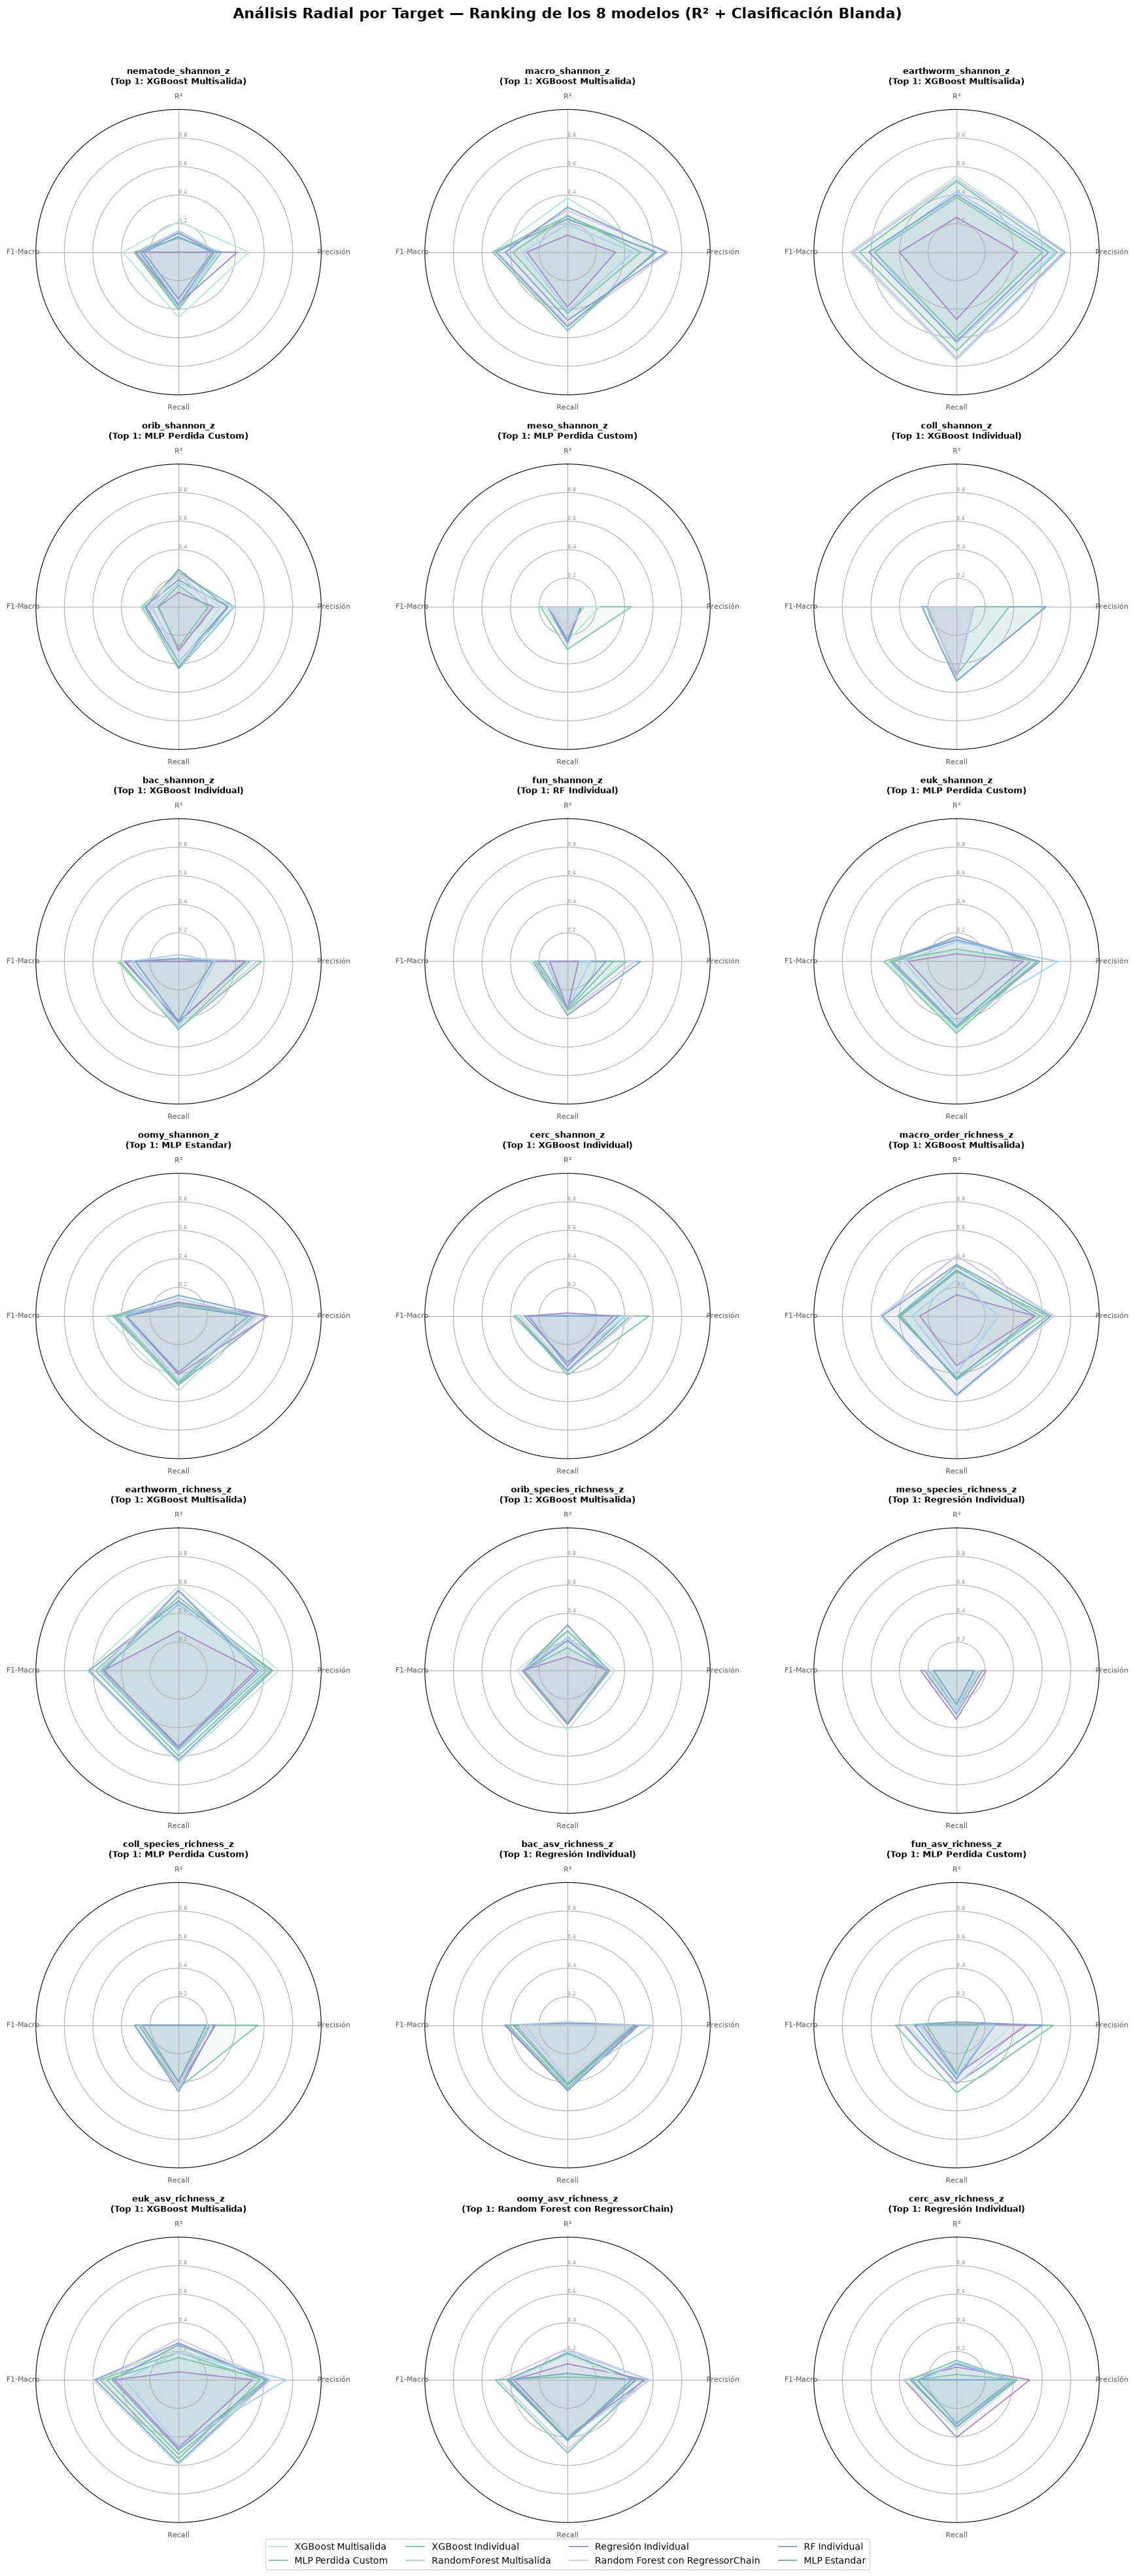

In [10]:
# Paso 7: Radar por target - Top 8 modelos (ranking completo de los 8 modelos, por target)
os.makedirs('output/regresion/graphs/por_target', exist_ok=True)

n_targets = len(TARGETS)
n_cols_t  = 3
n_rows_t  = int(np.ceil(n_targets / n_cols_t))

fig_t, axes_t = plt.subplots(n_rows_t, n_cols_t, figsize=(6 * n_cols_t, 5.5 * n_rows_t),
                              subplot_kw=dict(projection='polar'))
axes_t = axes_t.flatten()

print("  Top 8 modelos por target (R2 + Clasificación)  ")

for k, target in enumerate(TARGETS):
    ax = axes_t[k]
    df_t = (df_radar_target[df_radar_target['Target'] == target]
            .sort_values('Score_Compuesto', ascending=False)
            .reset_index(drop=True))

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    plt.sca(ax)
    plt.xticks(angulos[:-1], categorias, color=PALETTE['gray_dark'], size=8)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color=PALETTE['gray'], size=6)
    plt.ylim(0, 1)

    for i, fila in df_t.iterrows():
        valores_t = [max(0, fila['R2']), fila['Precision'], fila['Recall'], fila['F1_Macro']]
        valores_t += valores_t[:1]
        color_m = color_por_modelo[fila['Modelo']]
        ax.plot(angulos, valores_t, linewidth=1.4, linestyle='solid',
                color=color_m, label=fila['Modelo'] if k == 0 else None)
        ax.fill(angulos, valores_t, color=color_m, alpha=0.08)

    ax.set_title(f"{target}\n(Top 1: {df_t.iloc[0]['Modelo']})", fontsize=9, fontweight='bold', pad=10)

    # Dirgama de araña individual por target 
    fig_ind_t, ax_ind_t = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))
    ax_ind_t.set_theta_offset(np.pi / 2)
    ax_ind_t.set_theta_direction(-1)
    plt.sca(ax_ind_t)
    plt.xticks(angulos[:-1], categorias, color=PALETTE['gray_dark'], size=10)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color=PALETTE['gray'], size=8)
    plt.ylim(0, 1)
    for i, fila in df_t.iterrows():
        color_m = color_por_modelo[fila['Modelo']]
        valores_t = [max(0, fila['R2']), fila['Precision'], fila['Recall'], fila['F1_Macro']]
        valores_t += valores_t[:1]
        ax_ind_t.plot(angulos, valores_t, linewidth=2, linestyle='solid', color=color_m, label=fila['Modelo'])
        ax_ind_t.fill(angulos, valores_t, color=color_m, alpha=0.08)
    ax_ind_t.set_title(f"Análisis Radial por Target: {target}", fontsize=12, fontweight='bold', pad=15)
    ax_ind_t.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=7)
    fig_ind_t.tight_layout()
    fig_ind_t.savefig(f"output/regresion/graphs/por_target/radar_{target}.png", dpi=200, bbox_inches='tight')
    plt.close(fig_ind_t)

    # Ranking Top 8 impreso para este target
    print(f"\n{target}:")
    for i, fila in df_t.iterrows():
        print(f"  Top {i+1}: {fila['Modelo']:<35} | Compuesto: {fila['Score_Compuesto']:.4f} | "
              f"R2: {fila['R2']:>7.4f} | P: {fila['Precision']:.4f} | R: {fila['Recall']:.4f} | "
              f"F1: {fila['F1_Macro']:.4f}")

for j in range(n_targets, len(axes_t)):
    axes_t[j].set_visible(False)

handles, labels = axes_t[0].get_legend_handles_labels()
fig_t.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01), fontsize=10)
fig_t.suptitle("Análisis Radial por Target — Ranking de los 8 modelos (R² + Clasificación Blanda)",
               fontsize=16, fontweight='bold', y=1.01)
fig_t.tight_layout()
fig_t.savefig('output/regresion/graphs/mosaico_radar_por_target.png', dpi=250, bbox_inches='tight')
plt.show()


  Mejor model para cada target  
                 Target                           Modelo  Score_Compuesto        R2  Precision   Recall  F1_Macro
     nematode_shannon_z              XGBoost Multisalida         0.388895  0.216316   0.492593 0.457181  0.389491
        macro_shannon_z              XGBoost Multisalida         0.509552  0.379476   0.610211 0.525183  0.523340
    earthworm_shannon_z              XGBoost Multisalida         0.701781  0.532770   0.770330 0.757842  0.746183
         orib_shannon_z               MLP Perdida Custom         0.331694  0.242702   0.391813 0.435897  0.256365
         meso_shannon_z               MLP Perdida Custom         0.233772 -0.388202   0.446667 0.298148  0.190274
         coll_shannon_z               XGBoost Individual         0.347285 -0.309727   0.626984 0.520408  0.241747
          bac_shannon_z               XGBoost Individual         0.372428  0.021210   0.583614 0.474138  0.410749
          fun_shannon_z                    RF Individua

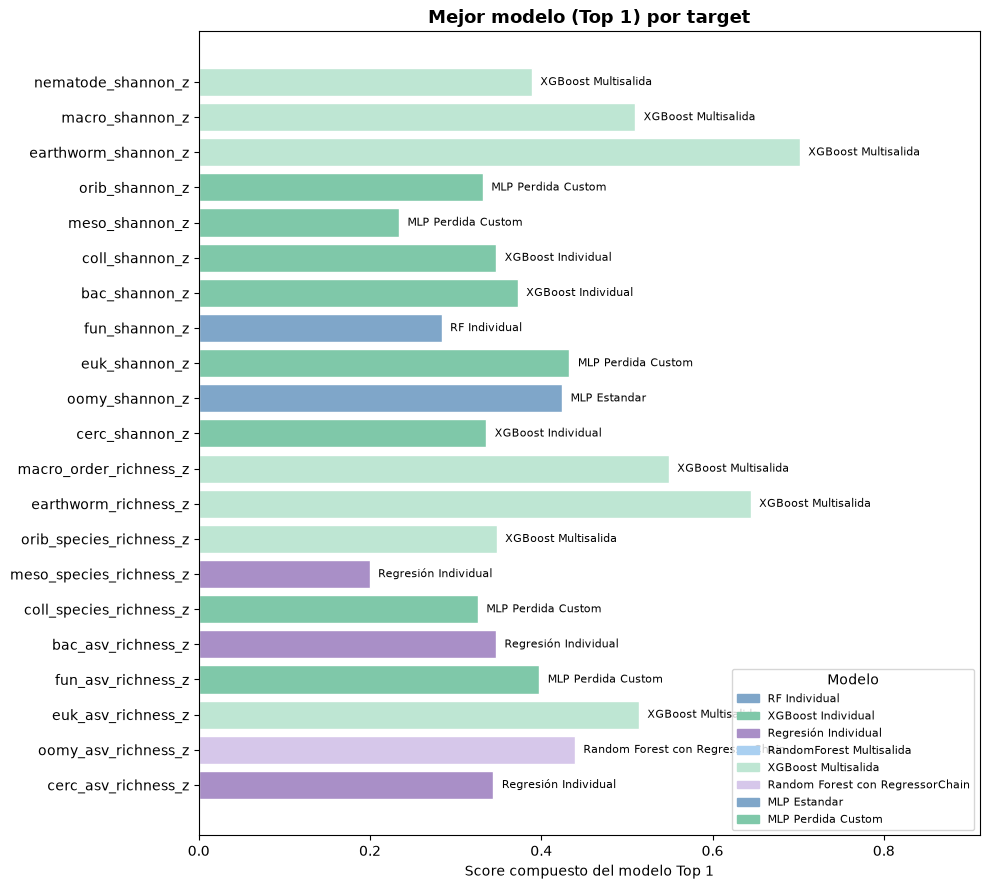


Resumen guardado en output/regresion/top1_modelo_por_target.csv


In [11]:
# Paso 8: Resumen - Top 1 modelo por cada target
df_top1_target = (
    df_radar_target.sort_values('Score_Compuesto', ascending=False)
    .groupby('Target', sort=False).first()
    .reindex(TARGETS)
    .reset_index()[['Target', 'Modelo', 'Score_Compuesto', 'R2', 'Precision', 'Recall', 'F1_Macro']]
)

print("  Mejor model para cada target  ")
print(df_top1_target.to_string(index=False))

conteo_top1 = df_top1_target['Modelo'].value_counts()
print("\nNumero de targets en los que cada modelo es el Top 1:")
for modelo, count in conteo_top1.items():
    print(f"  {modelo:<35}: {count} / {len(TARGETS)} targets")

# Grafico resumen: modelo Top 1 por target, coloreado por modelo (mismo color que en los radares)
fig, ax = plt.subplots(figsize=(10, 9))
colores_top1 = [color_por_modelo[m] for m in df_top1_target['Modelo']]
bars = ax.barh(df_top1_target['Target'], df_top1_target['Score_Compuesto'],
               color=colores_top1, edgecolor='white')
for bar, modelo in zip(bars, df_top1_target['Modelo']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, modelo, va='center', fontsize=8)
ax.set_xlabel('Score compuesto del modelo Top 1')
ax.set_title('Mejor modelo (Top 1) por target', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(df_top1_target['Score_Compuesto']) * 1.3)
ax.invert_yaxis()

handles = [plt.Rectangle((0, 0), 1, 1, color=color_por_modelo[m]) for m in modelos_lista]
ax.legend(handles, modelos_lista, loc='lower right', fontsize=8, title='Modelo')

plt.tight_layout()
os.makedirs('output/regresion/graphs', exist_ok=True)
fig.savefig('output/regresion/graphs/resumen_top1_por_target.png', dpi=250, bbox_inches='tight')
plt.show()

df_top1_target.to_csv('output/regresion/top1_modelo_por_target.csv', index=False)
print("\nResumen guardado en output/regresion/top1_modelo_por_target.csv")